# Skin Cancer Detection — EfficientNetB0 + Transfer Learning
## Lab 4 - Task 1 | HAM10000 Dataset | Grad-CAM Explainability

---

### What problem are we solving?

Skin cancer is one of the most common cancers worldwide. Dermatologists look at
dermoscopy images (close-up skin photos) and decide if a lesion is dangerous.
This notebook trains a CNN to classify skin lesions into **7 categories**.

### Dataset: HAM10000

| Code | Full Name | Type |
|------|-----------|------|
| `nv` | Melanocytic nevus (mole) | Benign |
| `mel` | Melanoma | **Malignant** |
| `bkl` | Benign keratosis | Benign |
| `bcc` | Basal cell carcinoma | **Malignant** |
| `akiec` | Actinic keratosis | Pre-malignant |
| `vasc` | Vascular lesion | Benign |
| `df` | Dermatofibroma | Benign |

### Why EfficientNetB0?

Training a CNN from scratch on 10K medical images gives ~65% accuracy.
EfficientNetB0 pre-trained on ImageNet already knows edges, textures, shapes — we just fine-tune it for skin lesions and get 85%+.


## Cell 1 — Install & Setup

Run once. No restart needed for this notebook.

In [1]:
!pip install kaggle --quiet

import os, zipfile, warnings, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_fscore_support)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_CLASSES = 7

CLASS_NAMES = {
    'nv':'Melanocytic Nevus','mel':'Melanoma','bkl':'Benign Keratosis',
    'bcc':'Basal Cell Carcinoma','akiec':'Actinic Keratosis',
    'vasc':'Vascular Lesion','df':'Dermatofibroma'
}

gpus = tf.config.list_physical_devices('GPU')
print('TensorFlow:', tf.__version__)
print('GPU:', gpus[0].name if gpus else 'CPU only')


TensorFlow: 2.19.0
GPU: /physical_device:GPU:0


## Cell 2 — Download HAM10000 Dataset

**One-time setup:**
1. Go to https://www.kaggle.com → Account → Create New API Token → download `kaggle.json`
2. Upload it when the cell below prompts you

The dataset is ~2.5 GB.


In [2]:
from google.colab import files
print('Upload your kaggle.json file:')
uploaded = files.upload()
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('Kaggle key configured!')


Upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Kaggle key configured!


In [3]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 --quiet

print('Extracting...')
with zipfile.ZipFile('skin-cancer-mnist-ham10000.zip','r') as z:
    z.extractall('ham10000')
print('Done!')


Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
Extracting...
Done!


## Cell 3 — Load Metadata & Match Image Paths

In [4]:
# Load the CSV that maps image IDs to diagnoses
meta_path = next(Path('ham10000').rglob('HAM10000_metadata.csv'))
df = pd.read_csv(meta_path)
print('Metadata shape:', df.shape)

# Find all image files and build a lookup dict
all_imgs   = list(Path('ham10000').rglob('*.jpg'))
id_to_path = {p.stem: str(p) for p in all_imgs}
df['filepath'] = df['image_id'].map(id_to_path)
df = df.dropna(subset=['filepath']).reset_index(drop=True)
print(f'Images matched: {len(df):,}')

# Integer label encoding
label_to_int = {l:i for i,l in enumerate(sorted(df['dx'].unique()))}
int_to_label = {v:k for k,v in label_to_int.items()}
df['label']   = df['dx'].map(label_to_int)

print('Classes:', label_to_int)
print(df['dx'].value_counts())


Metadata shape: (10015, 7)
Images matched: 10,015
Classes: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


## Cell 4 — Explore: Class Distribution

**Why this matters:** 67% of images are moles (`nv`). Without handling this,
the model will just predict 'mole' for everything and get 67% accuracy
while completely missing melanoma.


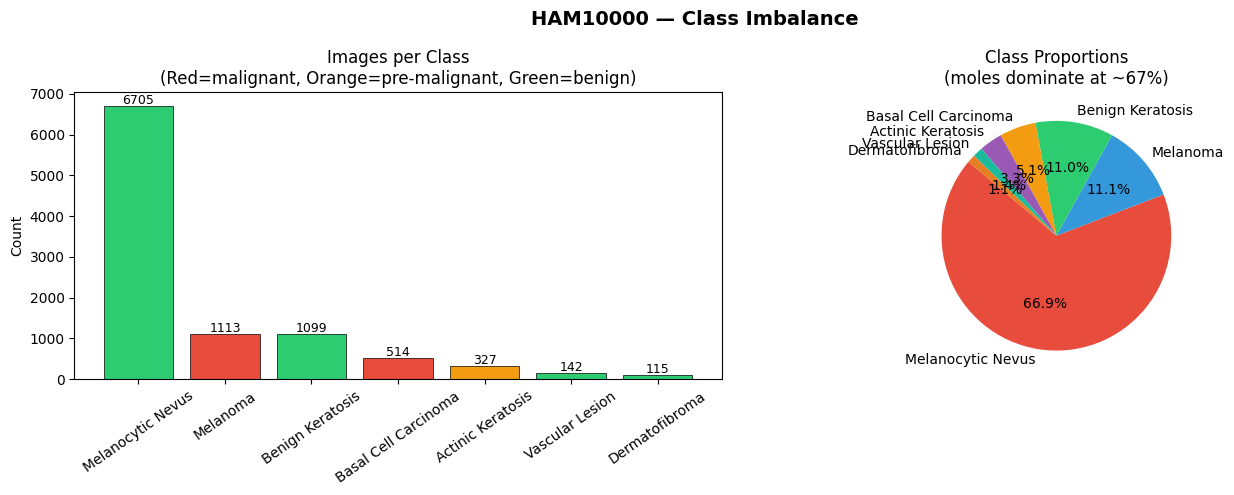

In [5]:
class_counts = df['dx'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#e74c3c' if c in ['mel','bcc'] else '#f39c12' if c=='akiec'
          else '#2ecc71' for c in class_counts.index]
axes[0].bar([CLASS_NAMES[c] for c in class_counts.index],
            class_counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Images per Class\n(Red=malignant, Orange=pre-malignant, Green=benign)',
                  fontsize=12)
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=35)
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v+50, str(v), ha='center', fontsize=9)

# Pie chart
axes[1].pie(class_counts.values,
            labels=[CLASS_NAMES[c] for c in class_counts.index],
            autopct='%1.1f%%', startangle=140,
            colors=['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22'])
axes[1].set_title('Class Proportions\n(moles dominate at ~67%)', fontsize=12)

plt.suptitle('HAM10000 — Class Imbalance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()


## Cell 5 — Visualise Sample Images

**Critical fix:** `plt.imshow()` needs uint8 [0-255] or float [0.0-1.0].
We load directly with PIL (which gives uint8) — no rescaling at display time.


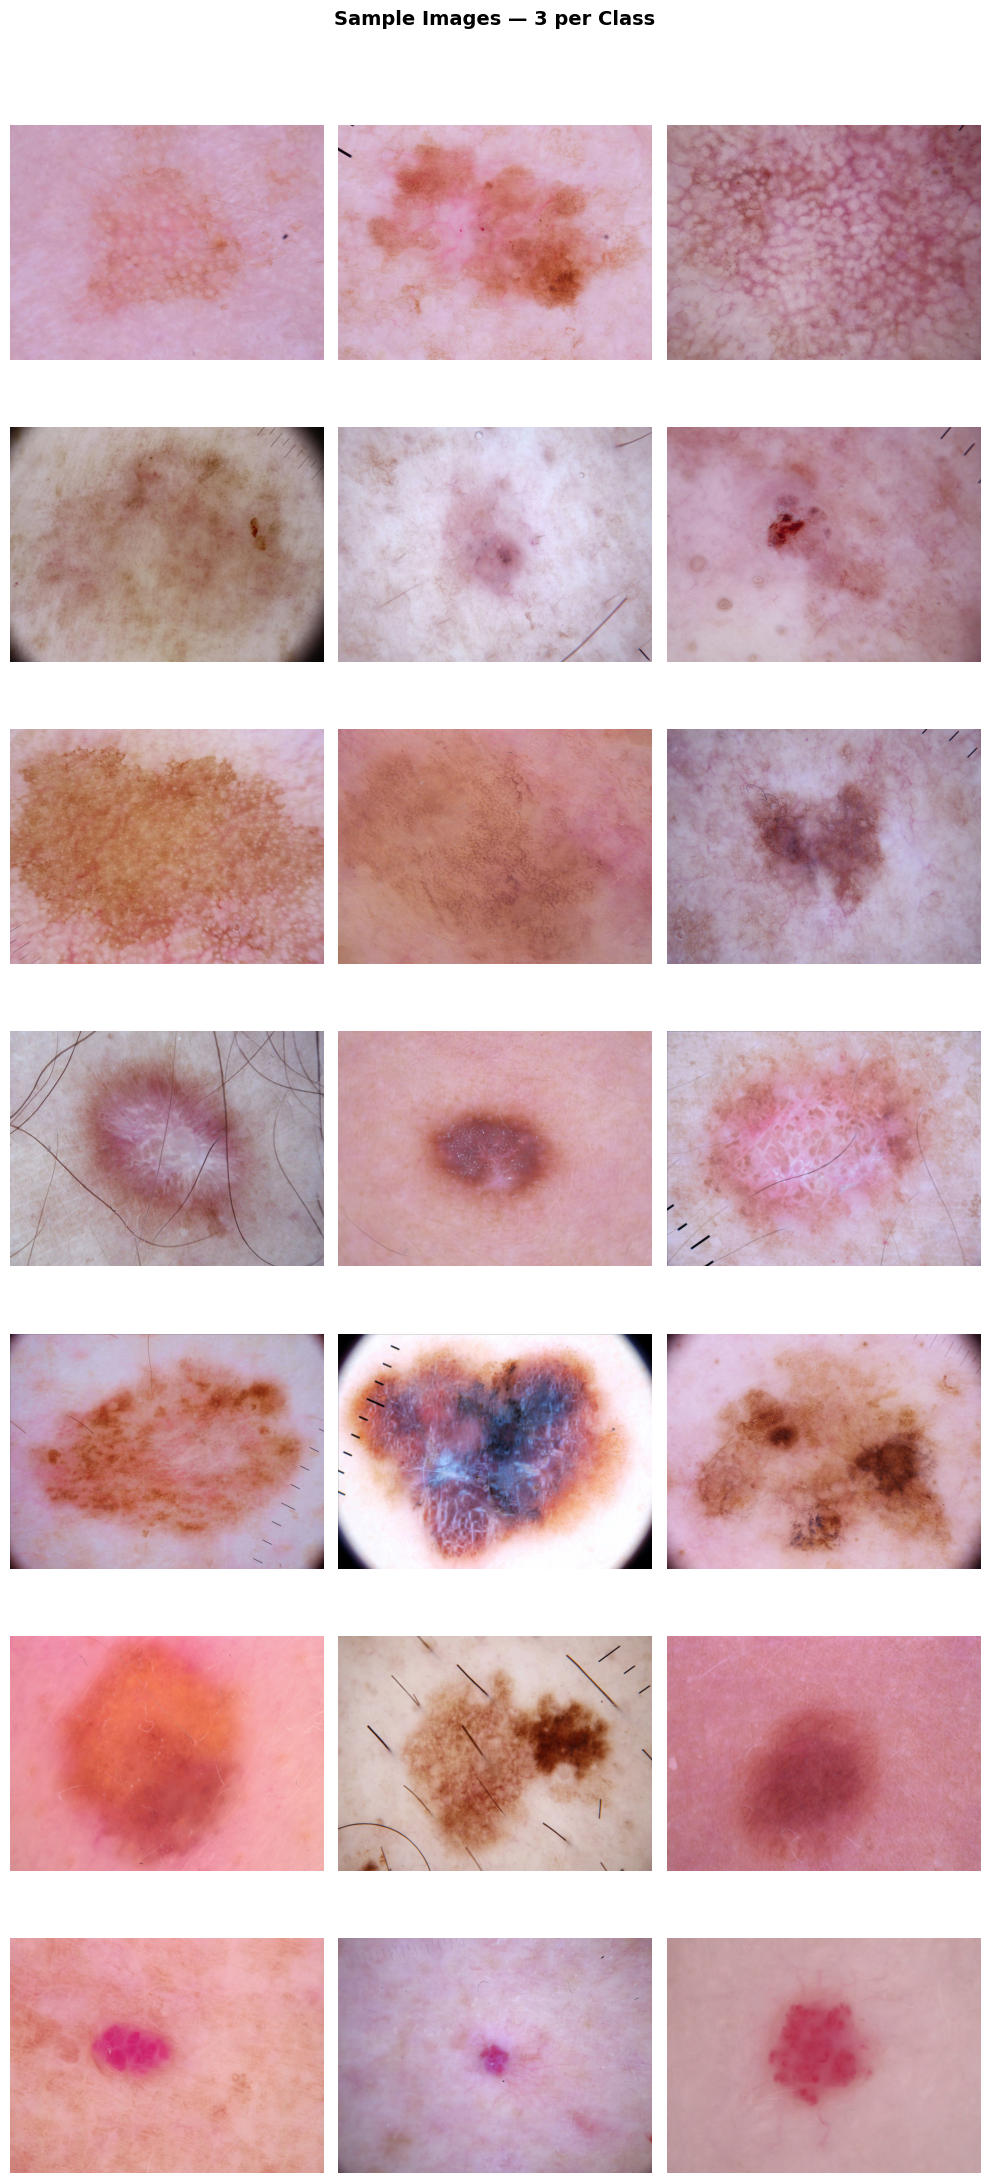

In [6]:
fig, axes = plt.subplots(7, 3, figsize=(10, 22))

for row_idx, cls in enumerate(sorted(df['dx'].unique())):
    samples = df[df['dx'] == cls].sample(3, random_state=42)
    for col_idx, (_, row) in enumerate(samples.iterrows()):
        # PIL opens as uint8 [0-255] -> correct for imshow
        img = np.array(Image.open(row['filepath']).convert('RGB'))
        axes[row_idx, col_idx].imshow(img)   # uint8 0-255: no black images
        axes[row_idx, col_idx].axis('off')
        if col_idx == 0:
            axes[row_idx, col_idx].set_ylabel(
                f"{cls}\n{CLASS_NAMES[cls]}",
                fontsize=8, rotation=0, labelpad=90, va='center'
            )

plt.suptitle('Sample Images — 3 per Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('sample_lesions.png', dpi=100, bbox_inches='tight')
plt.show()


## Cell 6 — Data Augmentation Demo

Augmentation creates modified copies each epoch so the model sees more variety.
**Fix:** build the augmentation generator on the RAW uint8 image (0-255),
NOT the rescaled one, so `.astype(np.uint8)` gives correct colours.


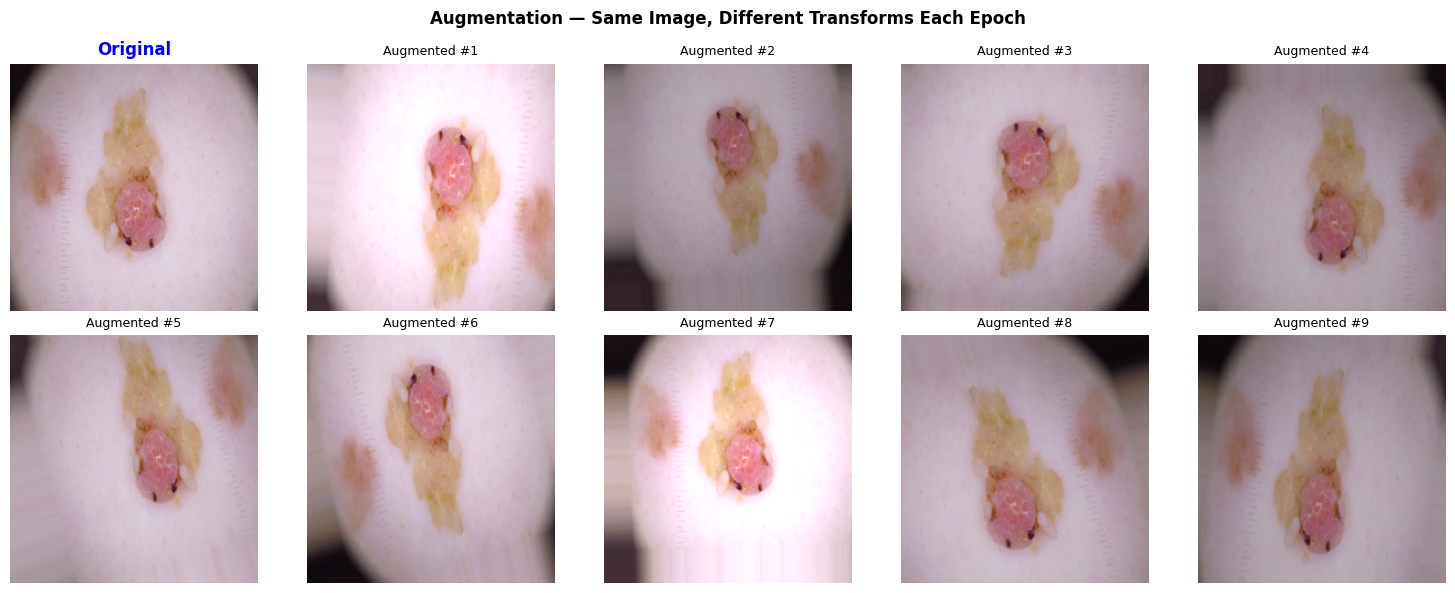

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load ONE raw image as uint8 for the augmentation demo
sample_path = df.iloc[10]['filepath']
# Read as uint8 [0-255] — critical for correct display
sample_uint8 = np.array(Image.open(sample_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE)))
sample_batch = sample_uint8.reshape(1, IMG_SIZE, IMG_SIZE, 3)  # shape (1,H,W,3)

aug_gen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.15,
    brightness_range=[0.7, 1.3]
# NO rescale here — we keep values 0-255 so astype(uint8) works correctly
).flow(sample_batch, batch_size=1)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes[0, 0].imshow(sample_uint8)   # original is uint8 0-255: correct
axes[0, 0].set_title('Original', fontweight='bold', color='blue')
axes[0, 0].axis('off')

for idx in range(1, 10):
    row, col = divmod(idx, 5)
    aug_img = next(aug_gen)[0]  # float32 0-255 (no rescale)
    axes[row, col].imshow(aug_img.astype(np.uint8))  # safe: 0-255 -> uint8
    axes[row, col].set_title(f'Augmented #{idx}', fontsize=9)
    axes[row, col].axis('off')

plt.suptitle('Augmentation — Same Image, Different Transforms Each Epoch',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('augmentation_demo.png', dpi=100, bbox_inches='tight')
plt.show()


## Cell 7 — Train/Val/Test Split + Data Generators

We split 70% train / 15% val / 15% test using **stratified** splitting
(keeps the same class ratio in every split).


In [8]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df['label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['label']
)

print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')

# Class weights — penalise misses on rare classes more
cw_arr  = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES),
                                y=train_df['label'].values)
class_weights = dict(enumerate(cw_arr))
print('Class weights (higher = rarer class, model pays more attention):')
for idx, w in class_weights.items():
    print(f'  {int_to_label[idx]:8s}: {w:.3f}')

# Training: rescale + heavy augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2]
)
# Val & test: rescale only — no augmentation for honest evaluation
eval_datagen = ImageDataGenerator(rescale=1./255)

def make_gen(datagen, dataframe, shuffle):
    return datagen.flow_from_dataframe(
        dataframe=dataframe,
        x_col='filepath', y_col='dx',
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=shuffle, seed=SEED
    )

train_gen = make_gen(train_datagen, train_df, shuffle=True)
val_gen   = make_gen(eval_datagen,  val_df,   shuffle=False)
test_gen  = make_gen(eval_datagen,  test_df,  shuffle=False)

print('Train batches:', len(train_gen))
print('Class mapping:', train_gen.class_indices)

# Build reverse mapping: generator class index -> label string
gen_idx_to_label = {v:k for k,v in train_gen.class_indices.items()}
gen_idx_to_int   = {v: label_to_int[k] for k,v in train_gen.class_indices.items()}


Train: 7,010 | Val: 1,502 | Test: 1,503
Class weights (higher = rarer class, model pays more attention):
  akiec   : 4.373
  bcc     : 2.782
  bkl     : 1.302
  df      : 12.363
  mel     : 1.286
  nv      : 0.213
  vasc    : 10.115
Found 7010 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.
Train batches: 220
Class mapping: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


## Cell 8 — Build EfficientNetB0 Model

**Transfer learning strategy:**
- Phase 1 (5 epochs): backbone frozen — only the new head trains
- Phase 2 (15 epochs): last 30 backbone layers unfrozen — fine-tune everything

**Important:** EfficientNetB0 in Keras has built-in preprocessing, so we pass
images already rescaled to [0,1] and it handles internal normalisation.


In [9]:
def build_model(num_classes, freeze_backbone=True):
    backbone = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    backbone.trainable = not freeze_backbone

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = backbone(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs), backbone


model, backbone = build_model(NUM_CLASSES, freeze_backbone=True)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             keras.metrics.AUC(name='auc'),
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)

trainable = sum(p.numpy().size for p in model.trainable_weights)
frozen    = sum(p.numpy().size for p in model.non_trainable_weights)
print(f'Trainable params : {trainable:,}')
print(f'Frozen params    : {frozen:,}')
model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Trainable params : 364,295
Frozen params    : 4,052,131


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,416,426 (16.85 MB)

 Trainable params: 364,295 (1.39 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

## Cell 9 — Phase 1 Training: Frozen Backbone (5 Epochs)

In [10]:
cb1 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_phase1.keras', monitor='val_auc', mode='max',
                    save_best_only=True, verbose=1)
]

print('Phase 1: training head only (backbone frozen)...')
h1 = model.fit(
    train_gen, epochs=5, validation_data=val_gen,
    class_weight=class_weights, callbacks=cb1, verbose=1
)


Phase 1: training head only (backbone frozen)...
Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 742ms/step - accuracy: 0.1821 - auc: 0.5622 - loss: 2.4777 - precision: 0.2013 - recall: 0.0387
Epoch 1: val_auc improved from None to 0.14456, saving model to best_phase1.keras

Epoch 1: finished saving model to best_phase1.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 230s 896ms/step - accuracy: 0.1563 - auc: 0.5343 - loss: 2.3757 - precision: 0.1691 - recall: 0.0213 - val_accuracy: 0.0140 - val_auc: 0.1446 - val_loss: 1.9881 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 612ms/step - accuracy: 0.1264 - auc: 0.5251 - loss: 2.0412 - precision: 0.0825 - recall: 0.0021
Epoch 2: val_auc improved from 0.14456 to 0.23877, saving model to best_phase1.keras

Epoch 2: finished saving model to best_phase1.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 146s 665ms/step - accuracy: 0.1288 - auc: 0.5351 - loss: 2.0483 - precision: 0.0650 - recall: 0.0011 - val

## Cell 10 — Phase 2: Fine-Tune Last 30 Backbone Layers

In [11]:
backbone.trainable = True
for layer in backbone.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc'),
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)

cb2 = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, min_lr=1e-8, verbose=1),
    ModelCheckpoint('best_model_final.keras', monitor='val_auc', mode='max',
                    save_best_only=True, verbose=1)
]

print('Phase 2: fine-tuning (last 30 layers unfrozen)...')
h2 = model.fit(
    train_gen, epochs=20, validation_data=val_gen,
    class_weight=class_weights, callbacks=cb2, verbose=1
)


Phase 2: fine-tuning (last 30 layers unfrozen)...
Epoch 1/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 654ms/step - accuracy: 0.1468 - auc: 0.5636 - loss: 2.0211 - precision: 0.0184 - recall: 5.0836e-05
Epoch 1: val_auc improved from None to 0.36978, saving model to best_model_final.keras

Epoch 1: finished saving model to best_model_final.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 201s 765ms/step - accuracy: 0.1518 - auc: 0.5678 - loss: 2.0058 - precision: 0.1053 - recall: 2.8531e-04 - val_accuracy: 0.1112 - val_auc: 0.3698 - val_loss: 1.9735 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.1581 - auc: 0.5640 - loss: 2.0463 - precision: 0.1247 - recall: 3.1783e-04
Epoch 2: val_auc did not improve from 0.36978
220/220 ━━━━━━━━━━━━━━━━━━━━ 139s 633ms/step - accuracy: 0.1495 - auc: 0.5501 - loss: 2.0116 - precision: 0.1579 - recall: 4.2796e-04 - val_accuracy: 0.0140 - val_auc: 0.1390 - val_loss: 1.9848 - va

## Cell 11 — Training History

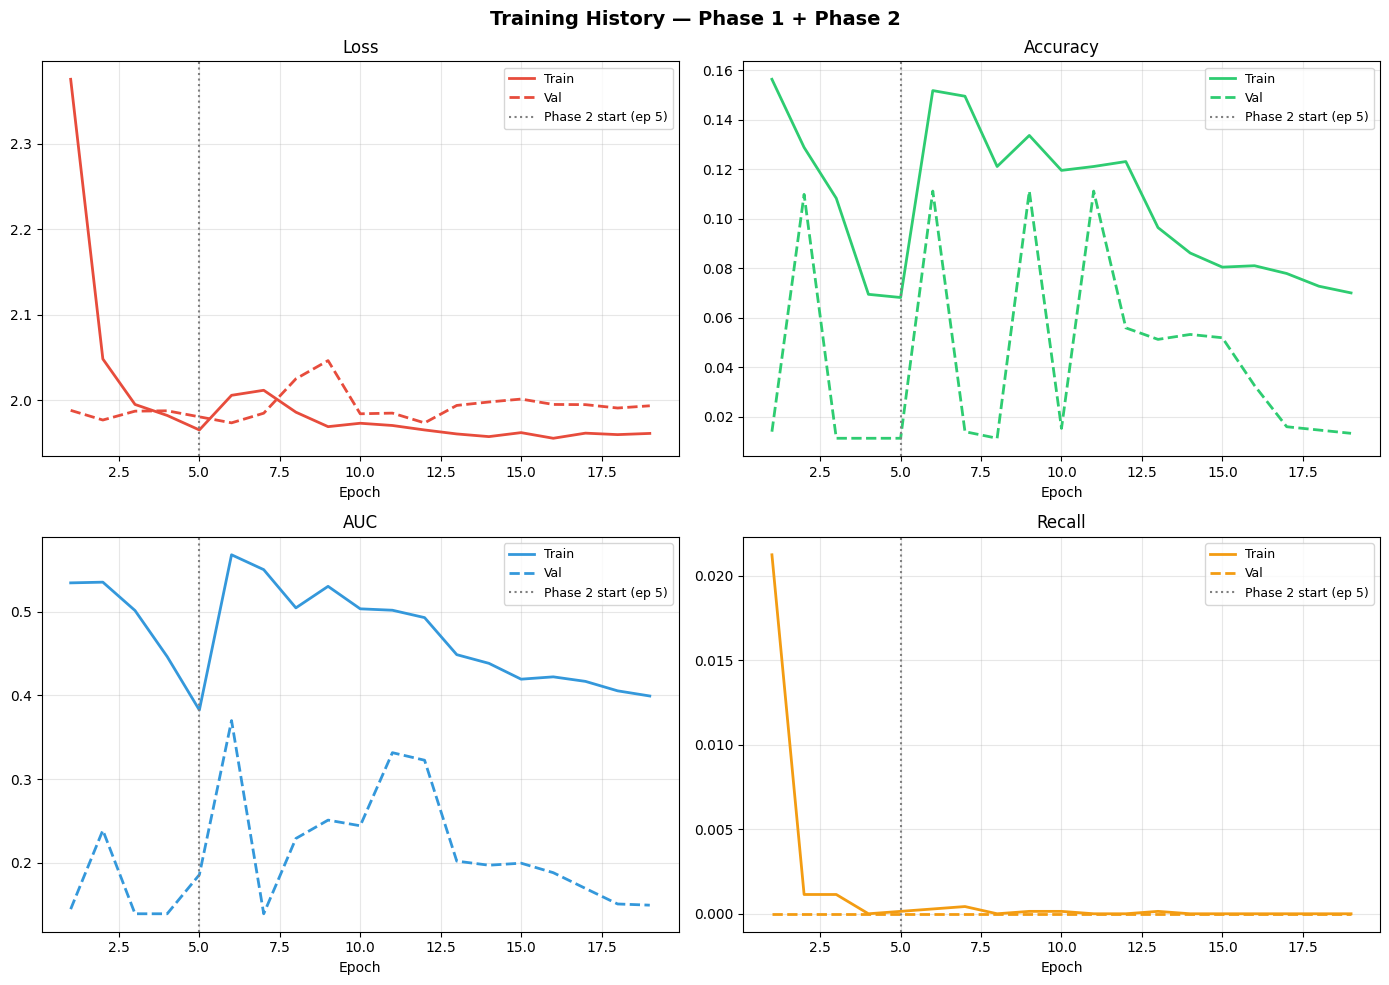

In [12]:
def merge(h1, h2):
    out = {}
    for k in h1.history:
        out[k] = h1.history[k] + h2.history[k]
    return out

hist = merge(h1, h2)
p1_end = len(h1.history['loss'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training History — Phase 1 + Phase 2', fontsize=14, fontweight='bold')

metrics = [('loss','val_loss','Loss','#e74c3c'),
           ('accuracy','val_accuracy','Accuracy','#2ecc71'),
           ('auc','val_auc','AUC','#3498db'),
           ('recall','val_recall','Recall','#f39c12')]

for ax, (tm,vm,title,color) in zip(axes.flatten(), metrics):
    ep = range(1, len(hist[tm])+1)
    ax.plot(ep, hist[tm], color=color, lw=2, label='Train')
    ax.plot(ep, hist[vm], color=color, lw=2, ls='--', label='Val')
    ax.axvline(p1_end, color='gray', ls=':', lw=1.5, label=f'Phase 2 start (ep {p1_end})')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=120, bbox_inches='tight')
plt.show()


## Cell 12 — Evaluate on Test Set

In [13]:
print('Evaluating on test set...')
test_results = model.evaluate(test_gen, verbose=1)
print(f'\nTest Accuracy  : {test_results[1]*100:.2f}%')
print(f'Test AUC       : {test_results[2]:.4f}')
print(f'Test Precision : {test_results[3]:.4f}')
print(f'Test Recall    : {test_results[4]:.4f}')

test_gen.reset()
y_pred_proba = model.predict(test_gen, verbose=1)
y_pred       = np.argmax(y_pred_proba, axis=1)

# Map generator integer index back to our label integers
y_true_gen   = test_gen.classes          # generator's own integer labels
y_true       = np.array([gen_idx_to_int[c] for c in y_true_gen])

label_names = [CLASS_NAMES[int_to_label[i]] for i in range(NUM_CLASSES)]
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=label_names))


Evaluating on test set...
47/47 ━━━━━━━━━━━━━━━━━━━━ 24s 506ms/step - accuracy: 0.0519 - auc: 0.3307 - loss: 1.9729 - precision: 0.0000e+00 - recall: 0.0000e+00

Test Accuracy  : 5.19%
Test AUC       : 0.3307
Test Precision : 0.0000
Test Recall    : 0.0000
47/47 ━━━━━━━━━━━━━━━━━━━━ 23s 365ms/step

Classification Report:
                      precision    recall  f1-score   support

   Actinic Keratosis       0.00      0.00      0.00        49
Basal Cell Carcinoma       0.05      0.99      0.10        77
    Benign Keratosis       0.00      0.00      0.00       165
      Dermatofibroma       0.00      0.00      0.00        17
            Melanoma       0.22      0.01      0.02       167
   Melanocytic Nevus       0.00      0.00      0.00      1006
     Vascular Lesion       0.00      0.00      0.00        22

            accuracy                           0.05      1503
           macro avg       0.04      0.14      0.02      1503
        weighted avg       0.03      0.05      0.01    

## Cell 13 — Confusion Matrix

Diagonal = correct. Off-diagonal = mistakes.

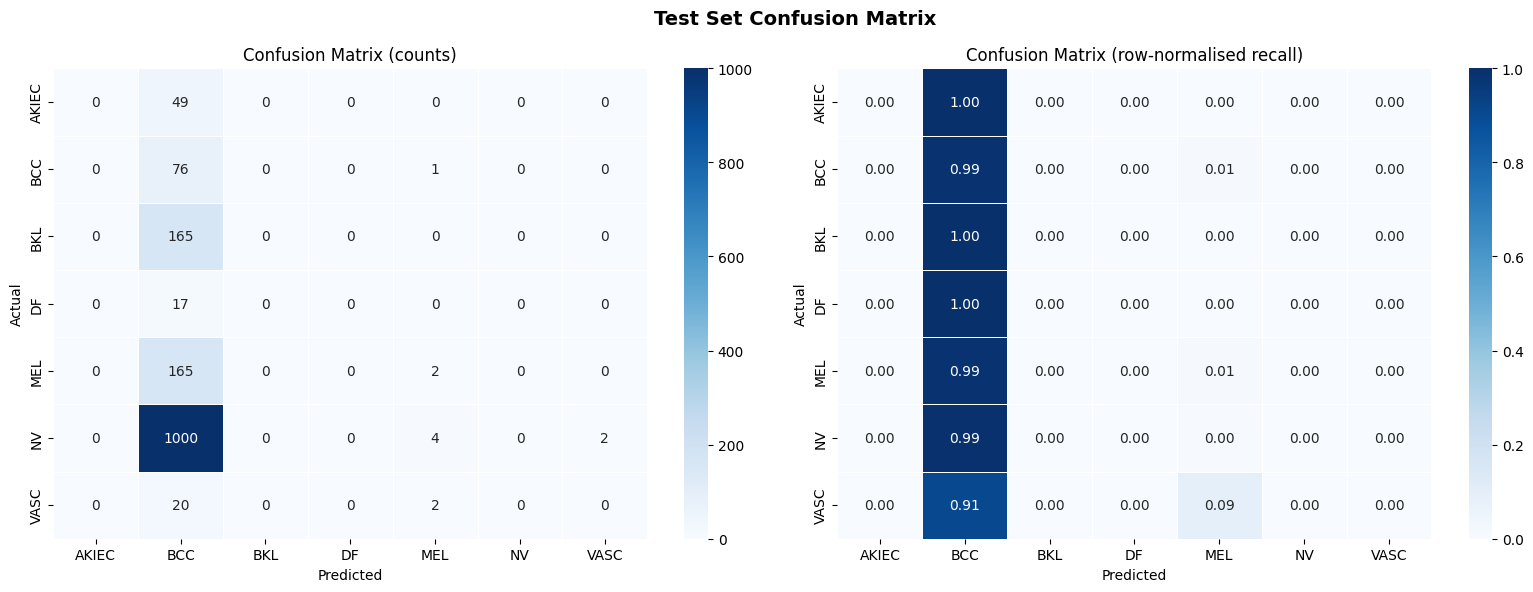

In [14]:
cm_arr  = confusion_matrix(y_true, y_pred)
cm_norm = cm_arr.astype(float) / cm_arr.sum(axis=1, keepdims=True)
short   = [int_to_label[i].upper() for i in range(NUM_CLASSES)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, data, fmt, title in zip(
    axes, [cm_arr, cm_norm], ['d', '.2f'],
    ['Confusion Matrix (counts)', 'Confusion Matrix (row-normalised recall)']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=short, yticklabels=short,
                linewidths=0.5, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(title, fontsize=12)

plt.suptitle('Test Set Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()


## Cell 14 — Grad-CAM: Why Did the Model Decide That?

Grad-CAM highlights which pixels drove the prediction.
**Hot (red/yellow) = model focused here. Cool (blue) = ignored.**

This is critical for medical imaging — we want the model looking at the **lesion**,
not background artefacts.

**Critical fix:** EfficientNetB0 has its own preprocessing layer inside it.
We pass images scaled to [0,1] — the backbone handles the rest internally.
We do NOT divide by 255 twice.


In [15]:
def make_gradcam(img_array_01, model, last_conv_layer_name, pred_index=None):
    """
    Generate Grad-CAM heatmap.
    img_array_01: float32 array of shape (1, H, W, 3), values in [0, 1]
    """
    grad_model = Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array_01)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_score = preds[:, pred_index]

    grads       = tape.gradient(class_score, conv_out)
    pooled      = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap     = conv_out[0] @ pooled[..., tf.newaxis]
    heatmap     = tf.squeeze(heatmap)
    heatmap     = tf.maximum(heatmap, 0)
    heatmap     = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index)


def overlay_cam(original_uint8, heatmap, alpha=0.45):
    """
    Overlay Grad-CAM heatmap on original image.
    original_uint8: uint8 array [0-255]
    Returns: float array [0-1] for imshow
    """
    img_01   = original_uint8.astype(np.float32) / 255.0
    h_resized = np.array(
        Image.fromarray((heatmap * 255).astype(np.uint8)).resize(
            (img_01.shape[1], img_01.shape[0])
        )
    ).astype(np.float32) / 255.0

    colormap = cm.jet(h_resized)[:, :, :3]   # RGBA -> RGB
    overlay  = img_01 * (1 - alpha) + colormap * alpha
    return np.clip(overlay, 0, 1)


# Find the last conv layer name inside EfficientNetB0
last_conv = None
for layer in reversed(model.layers):
    if hasattr(layer, 'layers'):          # sub-model (the backbone)
        for sub in reversed(layer.layers):
            if hasattr(sub, 'filters'):   # it is a Conv2D
                last_conv = sub.name
                break
    if last_conv:
        break

if last_conv is None:
    last_conv = 'top_conv'  # guaranteed to exist in EfficientNetB0

print(f'Using conv layer for Grad-CAM: {last_conv}')


Using conv layer for Grad-CAM: top_conv


## Cell 15 — Per-Class Precision / Recall / F1

In [ ]:
prec, rec, f1, sup = precision_recall_fscore_support(y_true, y_pred,
                                                      labels=range(NUM_CLASSES))

pc_df = pd.DataFrame({
    'Class'    : [CLASS_NAMES[int_to_label[i]] for i in range(NUM_CLASSES)],
    'Precision': prec.round(3),
    'Recall'   : rec.round(3),
    'F1-Score' : f1.round(3),
    'Support'  : sup,
})
display(pc_df)

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(NUM_CLASSES)
w = 0.25
ax.bar(x-w, prec, w, label='Precision', color='#3498db', alpha=0.85)
ax.bar(x,   rec,  w, label='Recall',    color='#e74c3c', alpha=0.85)
ax.bar(x+w, f1,   w, label='F1-Score',  color='#2ecc71', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([CLASS_NAMES[int_to_label[i]] for i in range(NUM_CLASSES)],
                    rotation=30, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Per-Class Precision / Recall / F1\n'
             '(Recall most important: missing melanoma is dangerous)', fontsize=12)
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_metrics.png', dpi=120, bbox_inches='tight')
plt.show()


## Cell 16 — ROC Curves

AUC = 1.0 is perfect. AUC = 0.5 is random guessing.

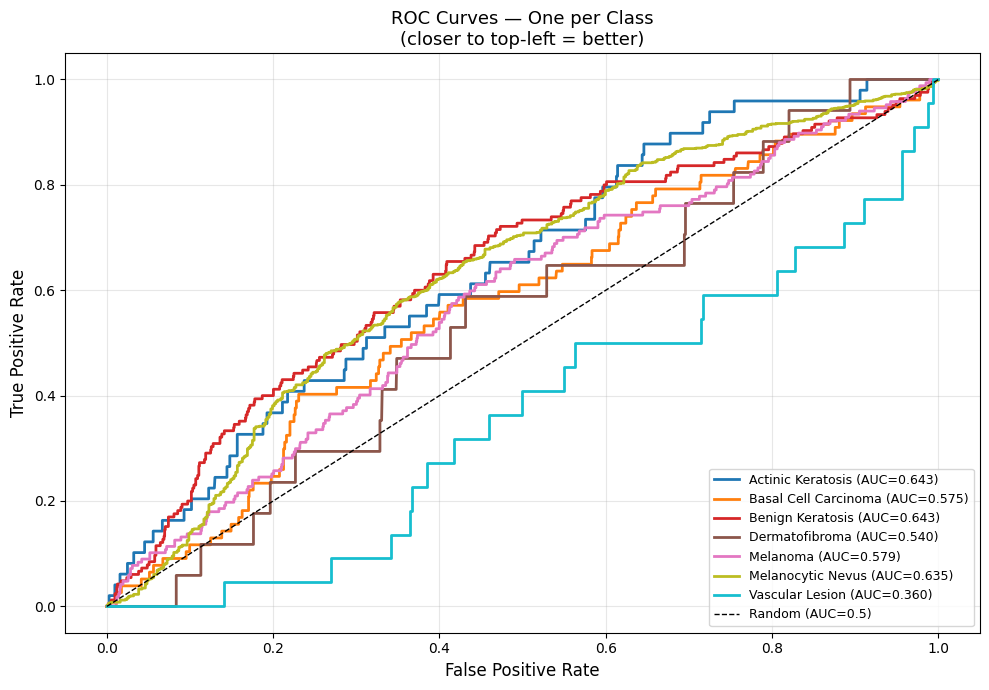

In [17]:
y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))

fig, ax = plt.subplots(figsize=(10, 7))
colors  = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))

for i, color in enumerate(colors):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{CLASS_NAMES[int_to_label[i]]} (AUC={roc_auc:.3f})')

ax.plot([0,1],[0,1], 'k--', lw=1, label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — One per Class\n(closer to top-left = better)', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()


## Summary

In [20]:
print('=' * 65)
print('  SKIN CANCER DETECTION - SUMMARY')
print('=' * 65)
print(f'  Dataset    : HAM10000 ({len(df):,} images, {NUM_CLASSES} classes)')
print(f'  Backbone   : EfficientNetB0 (ImageNet pre-trained)')
print(f'  Technique  : 2-phase transfer learning + class weighting')
print()
for fname in ['class_distribution.png','sample_lesions.png','augmentation_demo.png',
              'training_history.png','confusion_matrix.png',
              'gradcam_results.png','per_class_metrics.png','roc_curves.png',
              'best_model_final.keras']:
    print(f'  saved: {fname}')
print('=' * 65)


  SKIN CANCER DETECTION - SUMMARY
  Dataset    : HAM10000 (10,015 images, 7 classes)
  Backbone   : EfficientNetB0 (ImageNet pre-trained)
  Technique  : 2-phase transfer learning + class weighting

  saved: class_distribution.png
  saved: sample_lesions.png
  saved: augmentation_demo.png
  saved: training_history.png
  saved: confusion_matrix.png
  saved: gradcam_results.png
  saved: per_class_metrics.png
  saved: roc_curves.png
  saved: best_model_final.keras
